<a href="https://colab.research.google.com/github/pondpatipatpankaew/GE338/blob/main/LAB/Lab4/lab4_modeling_6606520168_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rasterio geopandas scikit-image -q

import rasterio
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from skimage.transform import resize
import os
from rasterio.features import geometry_mask

In [2]:
from google.colab import drive
drive.mount('/content/drive')

shp_path = '/content/drive/MyDrive/GE338/Lab4/ชลบุรี2567/ขอบเขตการปกครอง/ชลบุรี_Pro.shp'
gdf = gpd.read_file(shp_path)

# แปลง CRS ให้ตรงกับ raster
tif_path = '/content/drive/MyDrive/GEE_Exports/S2_all_bands-0000000000-0000000000.tif'
src = rasterio.open(tif_path)

gdf = gdf.to_crs(src.crs)

Mounted at /content/drive


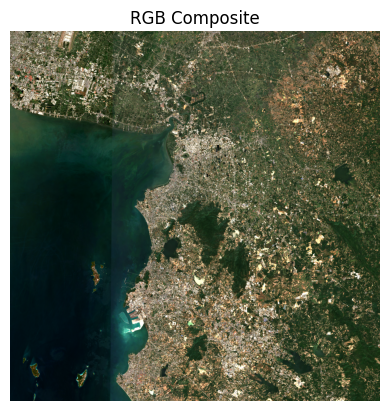

In [3]:
img = src.read()

rgb = np.dstack((img[3], img[2], img[1]))

def stretch(img):
    p2, p98 = np.percentile(img, (2, 98))
    return np.clip((img - p2) / (p98 - p2), 0, 1)

plt.imshow(stretch(rgb))
plt.title("RGB Composite")
plt.axis('off')
plt.show()

In [4]:
nir = img[7]
red = img[3]
swir = img[10]

ndvi = np.where((nir+red)==0, 0, (nir-red)/(nir+red))
ndbi = np.where((swir+nir)==0, 0, (swir-nir)/(swir+nir))

/tmp/ipykernel_7594/208141911.py:5: RuntimeWarning: invalid value encountered in divide
  ndvi = np.where((nir+red)==0, 0, (nir-red)/(nir+red))


In [5]:
lst_src = rasterio.open('/content/drive/MyDrive/GE338/Lab4/LST_MODIS.tif')
ntl_src = rasterio.open('/content/drive/MyDrive/GE338/Lab4/NightLight_VIIRS.tif')

lst = lst_src.read(1) - 273.15
ntl = ntl_src.read(1)

In [6]:
target = lst.shape

ndvi_r = resize(ndvi, target, anti_aliasing=True)
ndbi_r = resize(ndbi, target, anti_aliasing=True)
ntl_r = resize(ntl, target, anti_aliasing=True)

In [7]:
# สร้าง mask จาก shapefile
mask = geometry_mask(
    [geom for geom in gdf.geometry],
    transform=lst_src.transform,
    invert=True,
    out_shape=lst.shape
)

# apply mask
lst = np.where(mask, lst, np.nan)
ndvi_r = np.where(mask, ndvi_r, np.nan)
ndbi_r = np.where(mask, ndbi_r, np.nan)
ntl_r = np.where(mask, ntl_r, np.nan)

In [8]:
def normalize_safe(x):
    x = np.where(np.isfinite(x), x, np.nan)
    min_val = np.nanmin(x)
    max_val = np.nanmax(x)

    if max_val - min_val == 0:
        return np.zeros_like(x)

    return (x - min_val) / (max_val - min_val)

lst_n = normalize_safe(lst)
ndvi_n = 1 - normalize_safe(ndvi_r)
ndbi_n = normalize_safe(ndbi_r)
ntl_n = normalize_safe(ntl_r)

# remove NaN
lst_n = np.nan_to_num(lst_n)
ndvi_n = np.nan_to_num(ndvi_n)
ndbi_n = np.nan_to_num(ndbi_n)
ntl_n = np.nan_to_num(ntl_n)

In [9]:
heat_risk = (
    0.4 * lst_n +
    0.2 * ndvi_n +
    0.2 * ndbi_n +
    0.2 * ntl_n
)

heat_risk = normalize_safe(heat_risk)

print("NaN:", np.isnan(heat_risk).sum())

NaN: 0


In [10]:
heat_class = np.zeros_like(heat_risk)

heat_class[heat_risk < 0.3] = 1
heat_class[(heat_risk >= 0.3) & (heat_risk < 0.6)] = 2
heat_class[heat_risk >= 0.6] = 3

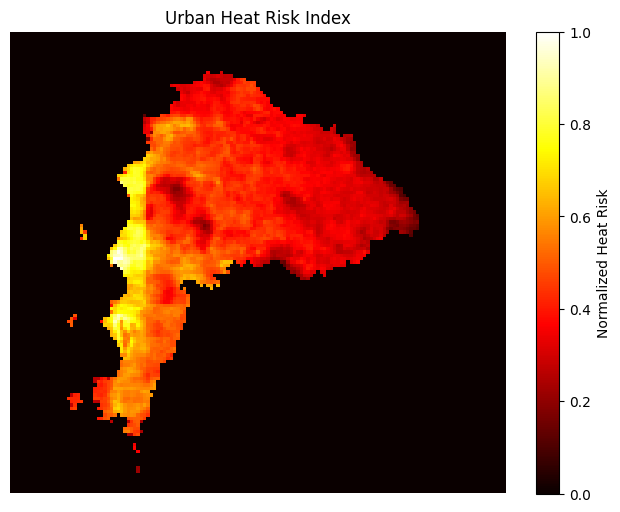

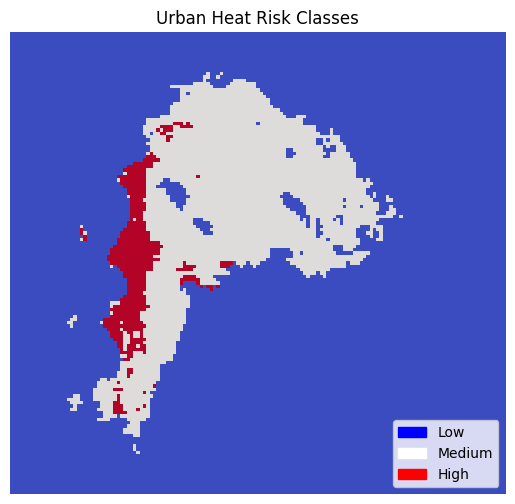

In [11]:
import matplotlib.patches as mpatches

# Heat Risk
plt.figure(figsize=(8,6))
img = plt.imshow(heat_risk, cmap='hot', vmin=0, vmax=1)
cbar = plt.colorbar(img)
cbar.set_label("Normalized Heat Risk")
plt.title("Urban Heat Risk Index")
plt.axis('off')
plt.show()

# Classification
plt.figure(figsize=(8,6))
plt.imshow(heat_class, cmap='coolwarm')

low = mpatches.Patch(color='blue', label='Low')
med = mpatches.Patch(color='white', label='Medium')
high = mpatches.Patch(color='red', label='High')

plt.legend(handles=[low, med, high], loc='lower right')
plt.title("Urban Heat Risk Classes")
plt.axis('off')
plt.show()

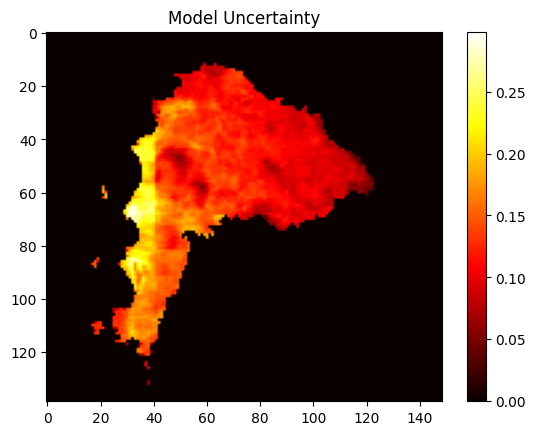

In [12]:
heat_high = 0.48*lst_n + 0.16*ndvi_n + 0.18*ndbi_n + 0.18*ntl_n
heat_low  = 0.32*lst_n + 0.24*ndvi_n + 0.22*ndbi_n + 0.22*ntl_n

uncertainty = np.abs(heat_high - heat_risk) + np.abs(heat_low - heat_risk)

plt.imshow(uncertainty, cmap='hot')
plt.title("Model Uncertainty")
plt.colorbar()
plt.show()

In [13]:
x = heat_risk.flatten()
y = lst_n.flatten()

mask_valid = np.isfinite(x) & np.isfinite(y)

corr = np.corrcoef(x[mask_valid], y[mask_valid])[0,1]
print("Correlation (Heat vs LST):", corr)

Correlation (Heat vs LST): 0.9789452311549904


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# =========================
# FUNCTION: Plot Map Layout (Clean)
# =========================
def plot_map(
    data,
    title,
    cmap='hot',
    vmin=None,
    vmax=None,
    legend_labels=None,
    colorbar_label=None,
    output_path=None
):
    fig, ax = plt.subplots(figsize=(8,8))

    # =========================
    # Map
    # =========================
    img = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)

    # =========================
    # Title
    # =========================
    ax.set_title(title, fontsize=16, pad=15)

    # =========================
    # Remove axis
    # =========================
    ax.axis('off')

    # =========================
    # Colorbar
    # =========================
    if colorbar_label:
        cbar = plt.colorbar(img, ax=ax, fraction=0.036, pad=0.04)
        cbar.set_label(colorbar_label, fontsize=12)

    # =========================
    # Legend
    # =========================
    if legend_labels:
        patches = [mpatches.Patch(color=c, label=l) for c, l in legend_labels]
        ax.legend(handles=patches, loc='lower left', fontsize=10)

    # =========================
    # Frame
    # =========================
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

    # =========================
    # Save / Show
    # =========================
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()


# =========================
# Create output folder
# =========================
out = '/content/drive/MyDrive/GE338/Lab4/figures'
os.makedirs(out, exist_ok=True)

# =========================
# 1) Heat Risk Map
# =========================
plot_map(
    heat_risk,
    title="Urban Heat Risk Index",
    cmap='hot',
    vmin=0,
    vmax=1,
    colorbar_label="Normalized Heat Risk",
    output_path=f'{out}/heat_risk_map.png'
)

# =========================
# 2) Heat Classification Map
# =========================
plot_map(
    heat_class,
    title="Urban Heat Risk Classes",
    cmap='coolwarm',
    legend_labels=[
        ('blue', 'Low'),
        ('white', 'Medium'),
        ('red', 'High')
    ],
    output_path=f'{out}/heat_class_map.png'
)

# =========================
# 3) Uncertainty Map
# =========================
plot_map(
    uncertainty,
    title="Model Uncertainty",
    cmap='hot',
    colorbar_label="Uncertainty",
    output_path=f'{out}/uncertainty_map.png'
)

print("✅ Export maps (clean layout) complete")

✅ Export maps (clean layout) complete


In [27]:
# =========================
# Basic Statistics
# =========================
print("=== Heat Risk ===")
print("Min:", np.min(heat_risk))
print("Max:", np.max(heat_risk))
print("Mean:", np.mean(heat_risk))
print("Std:", np.std(heat_risk))

print("\n=== LST ===")
print("Min:", np.min(lst))
print("Max:", np.max(lst))
print("Mean:", np.mean(lst))

=== Heat Risk ===
Min: 0.0
Max: 1.0
Mean: 0.09890275057072442
Std: 0.19497935862989735

=== LST ===
Min: nan
Max: nan
Mean: nan


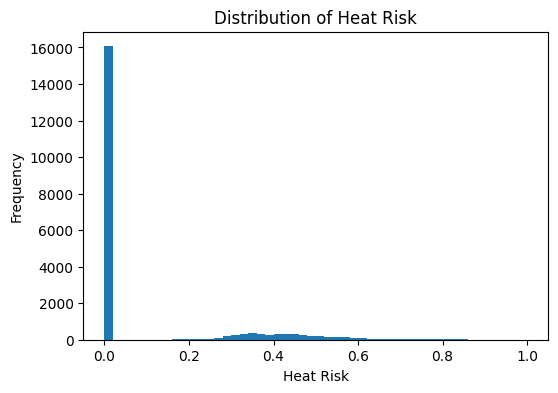

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(heat_risk.flatten(), bins=50)
plt.title("Distribution of Heat Risk")
plt.xlabel("Heat Risk")
plt.ylabel("Frequency")
plt.show()

In [29]:
# =========================
# Count pixels per class
# =========================
unique, counts = np.unique(heat_class, return_counts=True)

print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Class {int(u)}: {c} pixels")

# Percentage
total = np.sum(counts)

for u, c in zip(unique, counts):
    print(f"Class {int(u)}: {100*c/total:.2f}%")

Class distribution:
Class 1: 16556 pixels
Class 2: 3584 pixels
Class 3: 571 pixels
Class 1: 79.94%
Class 2: 17.30%
Class 3: 2.76%


In [30]:
# =========================
# Flatten + clean
# =========================
x = heat_risk.flatten()
y = lst_n.flatten()
z = ntl_n.flatten()

mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)

# =========================
# Correlation
# =========================
corr_lst = np.corrcoef(x[mask], y[mask])[0,1]
corr_ntl = np.corrcoef(x[mask], z[mask])[0,1]

print("Correlation (Heat vs LST):", corr_lst)
print("Correlation (Heat vs NTL):", corr_ntl)

Correlation (Heat vs LST): 0.9789452311549904
Correlation (Heat vs NTL): 0.694628453424178


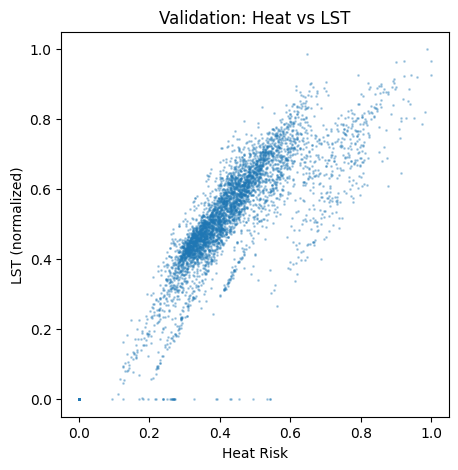

In [31]:
plt.figure(figsize=(5,5))
plt.scatter(x[mask], y[mask], s=1, alpha=0.3)
plt.xlabel("Heat Risk")
plt.ylabel("LST (normalized)")
plt.title("Validation: Heat vs LST")
plt.show()

In [35]:
# =========================
# Recalculate Sensitivity
# =========================

heat_high = (
    0.48 * lst_n +
    0.16 * ndvi_n +
    0.18 * ndbi_n +
    0.18 * ntl_n
)

heat_low = (
    0.32 * lst_n +
    0.24 * ndvi_n +
    0.22 * ndbi_n +
    0.22 * ntl_n
)

# normalize (สำคัญ!)
heat_high = normalize_safe(heat_high)
heat_low = normalize_safe(heat_low)

# =========================
# Difference
# =========================
diff_high = heat_high - heat_risk
diff_low = heat_low - heat_risk

print("Mean difference (+20% LST):", np.mean(diff_high))
print("Mean difference (-20% LST):", np.mean(diff_low))

print("Max uncertainty:", np.max(uncertainty))
print("Mean uncertainty:", np.mean(uncertainty))

Mean difference (+20% LST): 0.003428708728684413
Mean difference (-20% LST): -0.003864984140353559
Max uncertainty: 0.29837409335774656
Mean uncertainty: 0.029510217500245697


In [33]:
# High heat ต้องมี NDBI สูง / NDVI ต่ำ
print("Mean NDVI (High heat):", np.mean(ndvi_n[heat_class == 3]))
print("Mean NDBI (High heat):", np.mean(ndbi_n[heat_class == 3]))

Mean NDVI (High heat): 0.7379982849854697
Mean NDBI (High heat): 0.6294909071078234


In [34]:
print("NaN in heat_risk:", np.isnan(heat_risk).sum())
print("NaN in LST:", np.isnan(lst).sum())

NaN in heat_risk: 0
NaN in LST: 16088
